In [1]:
# Import required modules 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import os 
import matplotlib.lines as mlines
from datetime import datetime
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import FuncFormatter
import matplotlib.patches as patches

In [2]:
# Load the sampled ArcticDEM data and specify the dates to be plotted
elevation_data = pd.read_csv('R:/KOGE_BUGT/github/data/ArcticDEM_profiles/koge_bugt_C_ArcticDEM_10M.csv')
elevation_data.set_index('distance', inplace=True)
selected_columns = ['20160917', '20170929', '20190721', '20200720', '20210805', '20220914']
elevation_data_june = elevation_data[selected_columns]
max_distances_colours = {
    '20160917': (14100, '#023047'),
    '20170929': (12850, '#219ebc'),
    '20190721': (13600, '#a7c957'),
    '20200720': (12200, '#ee9b00'),
    '20210805': (12600, '#e85d04'),
    '20220914': (14250, '#d00000')}

# Load the ice surface and elevation data extracted from BedMachine v5. Calculate the flotation height. 
KBC_df = pd.read_csv('R:/KOGE_BUGT/github/data/BedMachine_profiles/150m/KBC_bed_elevation_150m.csv')
KBC_distance = KBC_df['distance']
KBC_bed = KBC_df['bed']
rho_ice = 917   # Density of ice in kg/m³
rho_ocean = 1025  # Density of seawater in kg/m³
mask = KBC_bed < 0
KBC_bed_negative = KBC_bed[mask]
KBC_distance_filtered = KBC_distance[mask]
flotation_thickness = - KBC_bed_negative * (rho_ocean / rho_ice)
flotation_height = KBC_bed_negative + flotation_thickness
x_values = KBC_distance/1000
y1_values = [-700] * len(KBC_bed)
y2_values = KBC_bed

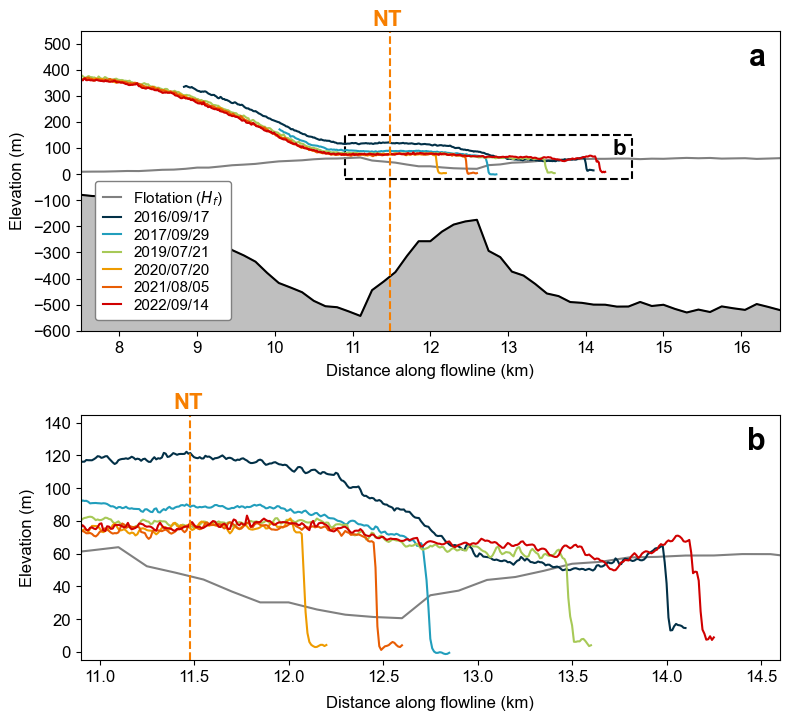

In [ ]:
# Plot Figure 3
plt.rcParams["font.family"] = "Arial"
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 7.3), sharex=False, sharey=False, gridspec_kw={'height_ratios': [1.1, 0.9]})

## Figure 3a
ax1.plot(KBC_distance/1000, KBC_bed, color='black')
ax1.fill_between(x_values, y1_values, y2_values, color='gray', alpha=0.5, zorder=1)
ax1.plot(KBC_distance_filtered/1000, flotation_height, color='gray', linewidth=1.5, label=r'Flotation ($H_f$)')
for column in elevation_data_june.columns:
    filtered_data = elevation_data_june[column]
    max_distance, color = max_distances_colours.get(column, (float('inf'), 'gray'))
    filtered_data = filtered_data[filtered_data.index <= max_distance]
    if not filtered_data.empty:
        date_formatted = datetime.strptime(column, '%Y%m%d').strftime('%Y/%m/%d')
        ax1.plot(filtered_data.index/1000, filtered_data, label=date_formatted, color=color, linewidth=1.5)
rect = patches.Rectangle((10.9, -20), 14.6-10.9, 150-(-20), facecolor='white', edgecolor='none', zorder=0)
ax1.add_patch(rect)
rect_outline = patches.Rectangle((10.9, -20), 14.6-10.9, 150-(-20), linewidth=1.5, edgecolor='black', facecolor='none', linestyle='--')
ax1.add_patch(rect_outline)
ax1.set_xlabel('Distance along flowline (km)', labelpad=6, fontsize=12)
ax1.set_ylabel('Elevation (m)', labelpad=6, fontsize=12)
ax1.set_xticks(range(8, 17, 1))
ax1.set_xlim(7.5, 16.5)
ax1.set_ylim(-600, 550)
ax1.set_yticks(range(-600, 550, 100))
ax1.tick_params(axis='x', labelsize=12)
ax1.tick_params(axis='y', labelsize=12)
ax1.axvline(x=11476.485/1000, color='#f77f00', linestyle='--')
ax1.text(0.98, 0.96, 'a', transform=ax1.transAxes, fontsize=22, fontweight='bold', va='top', ha='right')
ax1.text(0.78, 0.64, 'b', transform=ax1.transAxes, fontsize=16, fontweight='bold', va='top', ha='right')
ax1.text(0.46, 1.07, 'NT', transform=ax1.transAxes, color='#f77f00', fontsize=16, fontweight='bold', va='top', ha='right')

## Figure 3b
ax2.plot(KBC_distance/1000, KBC_bed, color='black')
ax2.fill_between(x_values, y1_values, y2_values, color='gray', alpha=0.5, zorder=1)
ax2.plot(KBC_distance_filtered/1000, flotation_height, color='gray', linewidth=1.5, label=r'Flotation ($H_f$)')
for column in elevation_data_june.columns:
    filtered_data = elevation_data_june[column]
    max_distance, color = max_distances_colours.get(column, (float('inf'), 'gray'))
    filtered_data = filtered_data[filtered_data.index <= max_distance]
    filtered_data_zoom = filtered_data[(filtered_data.index/1000 >= 10.9) & (filtered_data.index/1000 <= 14.5)]
    if not filtered_data_zoom.empty:
        date_formatted = datetime.strptime(column, '%Y%m%d').strftime('%Y/%m/%d')
        ax2.plot(filtered_data_zoom.index/1000, filtered_data_zoom, label=date_formatted, color=color, linewidth=1.5)
ax2.axvline(x=11476.485/1000, color='#f77f00', linestyle='--')
ax2.set_xlabel('Distance along flowline (km)', labelpad=8, fontsize=12)
ax2.set_ylabel('Elevation (m)', labelpad=6, fontsize=12)
ax2.set_xlim(10.9, 14.6)
ax2.set_ylim(-5, 145)
ax2.set_yticks(range(0, 145, 20))
ax2.tick_params(axis='x', labelsize=12)
ax2.tick_params(axis='y', labelsize=12)
ax2.text(0.98, 0.95, 'b', transform=ax2.transAxes, fontsize=22, fontweight='bold', va='top', ha='right')
ax2.text(0.175, 1.09, 'NT', transform=ax2.transAxes, color='#f77f00', fontsize=16, fontweight='bold', va='top', ha='right')

ax1.legend(fontsize=11, loc='lower left', bbox_to_anchor=(0.01, 0.01), facecolor='white', edgecolor='gray', fancybox=True, markerscale=2, handlelength=1.2, borderpad=0.5, labelspacing=0.23, framealpha=1)
plt.tight_layout()
#plt.savefig('R:/KOGE_BUGT/github/figures/Figure_3.png', dpi=300, bbox_inches='tight')
plt.show()